   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30

Student Clusters:
    Cluster  Hours  Scores
0         0    2.5      21
1         2    5.1      47
2         0    3.2      27
3         1    8.5      75
4         0    3.5      30
5         0    1.5      20
6         1    9.2      88
7         2    5.5      60
8         1    8.3      81
9         0    2.7      25
10        1    7.7      85
11        2    5.9      62
12        2    4.5      41
13        0    3.3      42
14        0    1.1      17
15        1    8.9      95
16        0    2.5      30
17        0    1.9      24
18        2    6.1      67
19        1    7.4      69
20        0    2.7      30
21        2    4.8      54
22        0    3.8      35
23        1    6.9      76
24        1    7.8      86


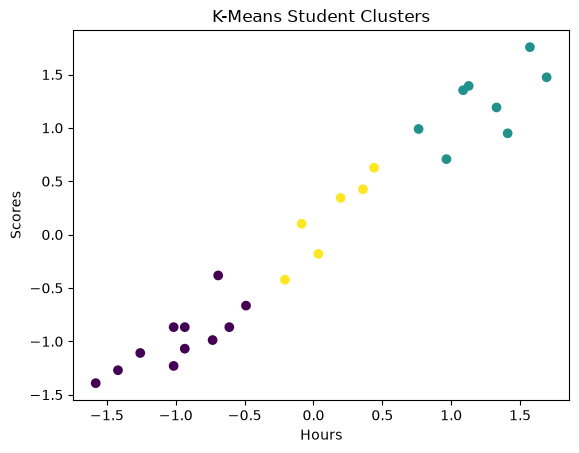


Done! Results saved.


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. Load dataset
df = pd.read_csv("studentscores.csv")
print(df.head())

# 3. K-Means on numerical columns
num = df.select_dtypes(include="number").columns
X = df[num].fillna(df[num].mean())

X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print("\nStudent Clusters:")
print(df[["Cluster"] + list(num)])

# 4. Plot clusters
plt.scatter(X[:, 0], X[:, 1], c=df["Cluster"])
plt.xlabel(num[0])
plt.ylabel(num[1])
plt.title("K-Means Student Clusters")
plt.show()

# 5. NLP - find text column
text_cols = df.select_dtypes(include="object").columns

if len(text_cols) > 0:
    text = df[text_cols[0]].fillna("")

    tfidf = TfidfVectorizer(stop_words="english")
    text_data = tfidf.fit_transform(text)

    nlp_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["NLP_Cluster"] = nlp_kmeans.fit_predict(text_data)

    print("\nNLP Clusters:")
    print(df[[text_cols[0], "NLP_Cluster"]])

# 6. Save results
df.to_csv("studentscores_clustered.csv", index=False)

print("\nDone! Results saved.")